Import Libraries


In [37]:
import torchvision
from torchvision.transforms import transforms
from torchvision import datasets
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random
import numpy as ns
import os
import time


In [38]:
os.makedirs(".images/gan",exist_ok=True)

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


**HyperParameter**

In [40]:
batch_size = 64
num_epochs = 30
image_size = 28 * 28  #784
latent_dim = 100
print_every = 5
n_show = 5

In [41]:
transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,),(0.5,))
])

In [42]:
data = datasets.MNIST(".data",train=True,download=True,transform=transforms)

In [43]:
data


Dataset MNIST
    Number of datapoints: 60000
    Root location: .data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [44]:
iterator = DataLoader(data, batch_size=batch_size,shuffle=True,drop_last=True)

In [45]:
len(iterator)

937

Generative

In [46]:
class Generator(nn.Module):
  def __init__(self, latent_dim, image_size):
    super().__init__()

    self.main = nn.Sequential(
        nn.Linear(latent_dim, 256),
        nn.LeakyReLU(0.2),

        nn.Linear(256, 512),
        nn.LeakyReLU(0.2),

        nn.Linear(512,1024),
        nn.LeakyReLU(0.2),

        nn.Linear(1024,image_size),
        nn.Tanh()
    )

  def forward(self,x):
    return self.main(x)

Discriminator

In [47]:
class Discriminator(nn.Module):
  def __init__(self, image_size):
    super().__init__()
    self.main = nn.Sequential(
        nn.Linear(image_size, 1024),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(1024, 512),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(512, 256),
        nn.LeakyReLU(0.2),
        nn.Dropout(0.3),

        nn.Linear(256, 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    return self.main(x)

In [48]:
G = Generator(latent_dim, image_size).to(device)
D = Discriminator(image_size).to(device)


Loss Function


In [49]:
criterion = nn.BCELoss()

**Optimizer**

In [50]:
G_optim = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.9999))

In [51]:
D_optim = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.9999))

**Label**

In [52]:
real = torch.ones(batch_size,1).to(device)
fake = torch.zeros(batch_size,1).to(device)
D_loss =[]
G_loss = []

function time

In [53]:
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_min = int(elapsed_time / 60)
  elapsed_secs = int(elapsed_time - (elapsed_min * 60))
  return elapsed_min, elapsed_secs

Epoch: 005 |G_loss: 1.815 |D_loss: 0.760 | Time: 0m 17s


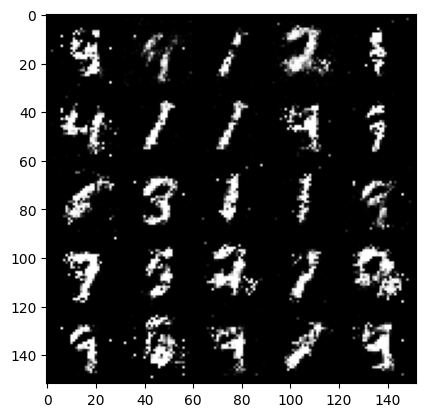

Epoch: 010 |G_loss: 1.385 |D_loss: 0.973 | Time: 0m 18s


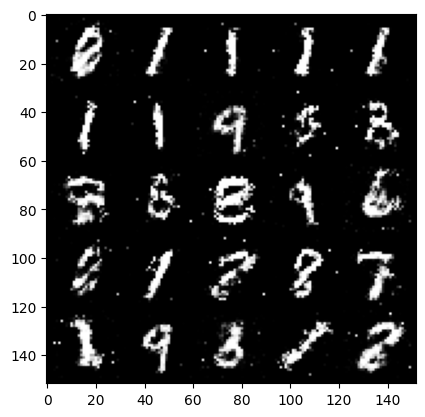

Epoch: 015 |G_loss: 1.203 |D_loss: 1.070 | Time: 0m 17s


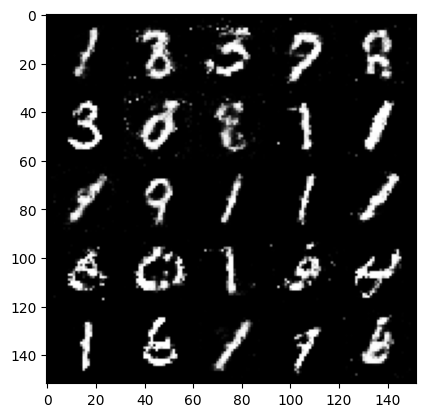

Epoch: 020 |G_loss: 1.078 |D_loss: 1.149 | Time: 0m 17s


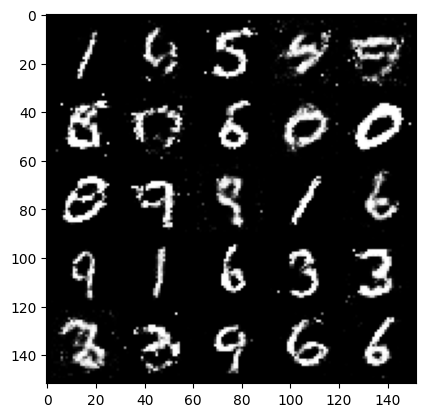

Epoch: 025 |G_loss: 1.039 |D_loss: 1.177 | Time: 0m 17s


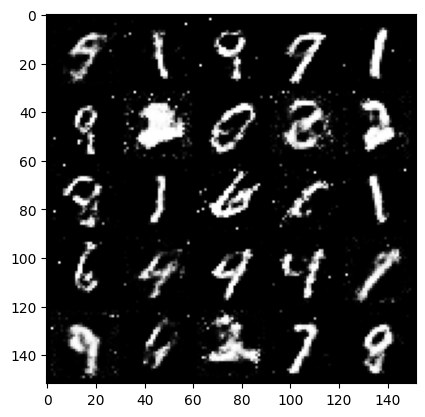

Epoch: 030 |G_loss: 1.017 |D_loss: 1.187 | Time: 0m 18s


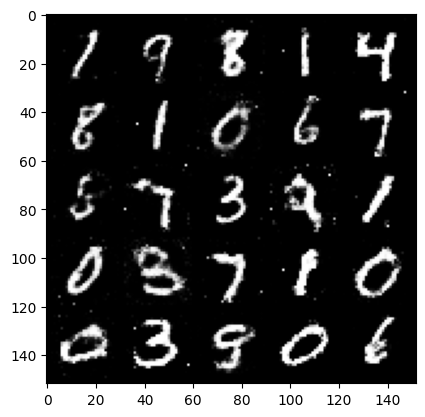

In [54]:
for epoch in range(1,num_epochs+1):
  start_time = time.time()
  Dl = 0
  Gl = 0
  for x,_ in iterator:
    #train Discriminator
    x = x.to(device)
    x = x.view(-1,image_size)
    z = torch.randn(x.shape[0],latent_dim).to(device)
    with torch.no_grad():
      generated_images = G(z)
    pred_real = D(x) #(batch_size, 1)
    D_error_real = criterion(pred_real, real)

    pre_fake = D(generated_images)
    D_error_fake = criterion(pre_fake, fake)

    D_error = D_error_real + D_error_fake
    D_optim.zero_grad()
    D_error.backward()
    D_optim.step()
    Dl += D_error.item()

    #train Generator

    #train_generator
    G_optim.zero_grad()
    z = torch.randn(x.shape[0],latent_dim).to(device)
    generated_images = G(z)
    pred_fake = D(generated_images)
    G_error = criterion(pred_fake, real)
    G_error.backward()
    G_optim.step()
    Gl += G_error.item()

  end_time = time.time()
  elapsed_min, elapsed_secs = epoch_time(start_time, end_time)

  D_loss.append(Dl/len(iterator))
  G_loss.append(Gl/len(iterator))

  if epoch % print_every == 0:

    z = torch.randn(n_show * n_show, latent_dim).to(device)

    with torch.no_grad():
      generated_images = G(z)

    generated_images = generated_images.view(-1, 1, 28, 28) #(batch_size, 1 ,28,28)

    print(f"Epoch: {epoch:03} |G_loss: {Gl/len(iterator):.03f} |D_loss: {Dl/len(iterator):.03f} | Time: {elapsed_min}m {elapsed_secs}s")

    torchvision.utils.save_image(generated_images, f".images/gan/epoch{epoch:03}.png",nrow=n_show,normalize=True)

    #display images
    img = plt.imread(f".images/gan/epoch{epoch:03}.png")
    plt.imshow(img)
    plt.show()



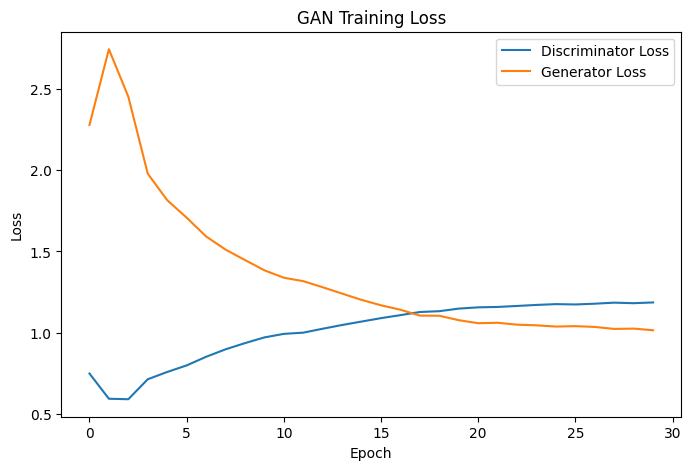

In [55]:


plt.figure(figsize=(8,5))

plt.plot(D_loss, label="Discriminator Loss")
plt.plot(G_loss, label="Generator Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GAN Training Loss")
plt.legend()

plt.show()